In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections.abc import Callable
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec
from scipy.linalg import eig, eigvals
import scipy.sparse.linalg as sc
from scipy.integrate import ode, solve_ivp
from scipy.interpolate import PchipInterpolator

In [3]:





def dip_derivative_full(Delta_R_vec: np.ndarray, i: int, j: int, d: np.ndarray,interaction_radius=None) -> float:
    Del_R = np.linalg.norm(Delta_R_vec)

    if Del_R==0:
        return 0
    elif interaction_radius and Del_R > interaction_radius + 0.01:
        return 0
    potential = 0

    if i == j:
        potential += 3/ Del_R**5-15*np.dot(d,Delta_R_vec)**2/Del_R**7
    potential += 6/ Del_R**5*d[i]*d[j]
    potential -= 30*(d[i]*Delta_R_vec[j]+d[j]*Delta_R_vec[i])*np.dot(d,Delta_R_vec)/Del_R**7
    potential -= 15*Delta_R_vec[i]*Delta_R_vec[j]*(1/Del_R**7-7*np.dot(d,Delta_R_vec)**2/Del_R**9)
    # return Del_R
    return potential

def dip_dip(r_vec,d):
    r = np.linalg.norm(r_vec)
    if r==0:
        return 0
    potential = 1/r**3 * (1- 3*(np.dot(d,r_vec)/r)**2)
    return potential


def dipole_trap_onsite(i: int, j:int) -> float:
    if i==j:
        return 1
    else:
        return 0

def max_phi(r):
    return min(np.arccos((np.sqrt(1+2*r**2)-1)/2/r),np.arccos((r-1)/r))

def d_1(a,e):
    d = 0.9
    r1 = np.sqrt(a**2+e**2)
    r2 = np.sqrt(1+e**2)
    A = 12*(1/r1**5+1/r2**5)-7*15*(a**2*e**2/r1**9+e**2/r2**9)
    B = 15*(a*e/r1**7-e/r2**7)
    res =  B**2*(1-d**2)/(A**2*d**2+B**2*(1-d**2))
    return np.array([np.sqrt(res),np.where(A*B>=0,1,-1)*np.sqrt(1-res)])

def interaction_rotated(DelR,i,j,interaction_radius,d1):
    r = np.sqrt(DelR[0]**2+DelR[1]**2)
    d2 =0.9
    if r ==0:
        return 0
    if r>interaction_radius+0.01:
        return 0

    if i==j:
        B = -3/r**5+15*DelR[i]**2/r**7
        A = 45*DelR[0]*DelR[1]/r**7-7*15*DelR[0]*DelR[1]*DelR[i]**2/r**9
        return A*d1[0]*d2 - B*d1[1]*np.sqrt(1-d2**2)
    else:
        A = 12/r**5-7*15*DelR[0]**2*DelR[1]**2/r**9
        B = 15 *DelR[0]*DelR[1]/r**7
        return d1[0]*d2*A-B*d1[1]*np.sqrt(1-d2**2)
    

def phi_1(a,e):
    r1 = np.sqrt(a**2+e**2)
    r2 = np.sqrt(1+e**2)
    B = (12*(1/r1**5+1/r2**5)-7*15*(a**2*e**2/r1**9+e**2/r2**9))*(-1)
    A = 45*(a*e/r1**7-e/r2**7)-7*15*(a**3*e/r1**9-e/r2**9)
    res =  np.arctan(A/B)+np.where(B>=0,1,-1)*np.pi*(1-np.where(B>=0,1,-1))/2
    return res

def d_plane(a,e):
    d = 0.7
    phi = phi_1(a,e)
    return d*np.array([np.cos(phi),np.sin(phi)])

def phi_2(r,phi):
    B  = (-1)*(24/r**5-7*15*np.cos(phi)**2*np.sin(phi)**2/r**5)
    A = 45*np.cos(phi)*np.sin(phi)/r**5-7*15*np.cos(phi)**3*np.sin(phi)/r**5
    res =  np.arctan(A/B)+np.where(B>=0,1,-1)*np.pi*(1-np.where(B>=0,1,-1))/2
    return res

def d_plane_2(r,phi):
    d = 0.7
    phi_d = phi_2(r,phi)
    return d*np.array([np.cos(phi_d),np.sin(phi_d)])

def interaction_dipplain(DelR,i,j,interaction_radius,d):
    r = np.sqrt(DelR[0]**2+DelR[1]**2)
    if r ==0:
        return 0
    if r>interaction_radius+0.01:
        return 0
    
    
    if i==j:
        A = -3/r**5+15*(DelR[0]**2+DelR[i]*DelR[0]*2+ DelR[i]**2)/r**7-7*15*DelR[0]**2*DelR[i]**2/r**9
        B = 15*DelR[0]*DelR[1]/r**7-7*15*DelR[0]*DelR[1]*DelR[i]**2/r**9
        if i==0:
            A += 15*2*DelR[0]**2/r**7-6/r**5
            B += 30*DelR[0]*DelR[1]/r**7
        return A*d[0] + B*d[1]
    else:
        B = 12/r**5-7*15*DelR[0]**2*DelR[1]**2/r**9
        A = 45*DelR[0]*DelR[1]/r**7-7*15*DelR[0]**3*DelR[1]/r**9
        return A*d[0] + B*d[1]  
    
def max_b(h,a):
    return np.sqrt((a-0.011)**2-h**2)

def Vxy_decomp(x,y):
    r = np.sqrt(x**2+y**2)
    A = 24/r**5-7*30*x**2*y**2/r**9
    C = 45*x*y/r**7
    B = -7*15*x**3*y/r**9
    D = -7*15*x*y**3/r**9
    return np.array([A, B, C, D])

def Vxy(DelR,d):
    A, B, C, D = Vxy_decomp(DelR[0],DelR[1])
    return A*d[0]*d[1]+C+B*d[0]**2+D*d[1]**2

def Vaa(DelR,i,d):
    r = np.sqrt(DelR[0]**2+DelR[1]**2)
    A = -3/r**5+15*(DelR[0]**2*d[0]**2+DelR[1]**2*d[1]**2+2*DelR[0]*DelR[1]*d[0]*d[1])/r**7
    B = -6*d[i]**2/r**5+30*(2*d[i]*DelR[i]*(DelR[0]*d[0]+DelR[1]*d[1]))/r**7
    C = 15*(DelR[i]**2/r**7-7*DelR[i]**2*(DelR[0]**2*d[0]**2+DelR[1]**2*d[1]**2+2*DelR[0]*DelR[1]*d[0]*d[1])/r**9)
    return A+B+C

def interaction_aligned_dip(DelR,i,j,interaction_radius,beta,d):
    r = np.linalg.norm(DelR)
    
    if r ==0:
        return 0
    if r>interaction_radius+0.01:
        return 0
    if i==j:
        return Vaa(DelR,i,d)*beta
    else:
        return Vxy(DelR,d)*beta


def d_aligned(b,h,a):
    A, B, C, D = Vxy_decomp(b,h)+Vxy_decomp(b-a,h)
    a = (D-B)**2+A**2
    bi = -(A**2+2*(C+D)*(D-B))
    c = (C+D)**2
    sq = np.sqrt(bi**2-4*a*c)
    ot = -bi
    dx = np.sqrt((ot+sq)/2/a)
    sign = np.where((-(C+D)+(D-B)*dx**2)*A>=0,1,-1)
    return np.array([dx,np.sqrt(1-dx**2)*sign])



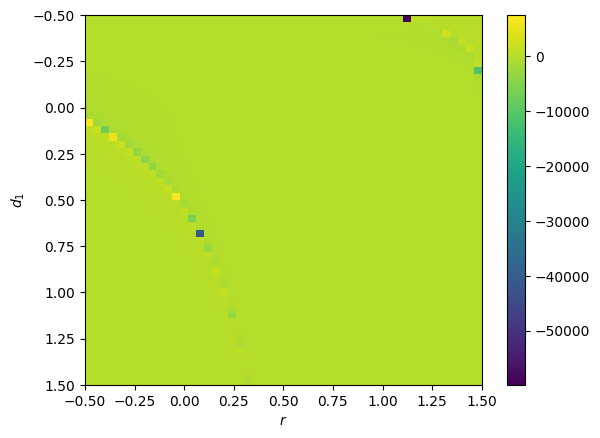

In [4]:
N = 50
h = 0.2
def max_der(R,d):
    items = []
    for i in range(2):
        for j in range(2):
            items.append(np.abs(dip_derivative_full(R,i,j,d,100)))
    return items[0]#max(items)
R = np.stack((np.linspace(0,1,N),np.ones(N)*h))
d1 = np.linspace(0,1,N)
d = np.array([np.sqrt(1/3),np.sqrt(2/3)])

V = np.zeros((N,N))
V_der = np.zeros((N,N))
for i in range(N):#
    for j in range(N):
        V[i,j] = dip_dip(R[:,i],np.array([d1[j],np.sqrt(1-d1[j]**2)]))
        V_der[i,j] = max_der(R[:,i],np.array([d1[j],np.sqrt(1-d1[j]**2)]))

fig, ax = plt.subplots(1,1)
im = ax.imshow(V_der/V,extent=(-0.5,1.5,1.5,-0.5),aspect='auto')
ax.set_xlabel(r'$r$')
ax.set_ylabel(r'$d_1$')
plt.colorbar(im,ax=ax)
plt.show()

# fig, ax = plt.subplots(1,2)
# for i in range(N):#
#     ax[0].scatter(R[0,i],max_der(R[:,i],d)/dip_dip(R[:,i],d),color='0')
#     ax[1].scatter(R[0,i],dip_dip(R[:,i],d),color='0')
# plt.show()


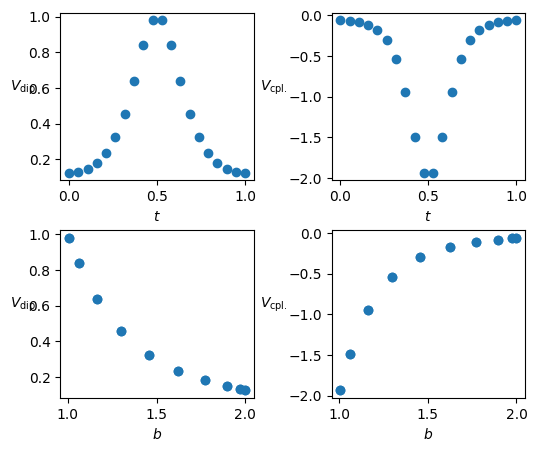

In [5]:
from scipy.optimize import minimize
def ratio(x,rx):
    h = x[0]
    d = np.array([np.sin(x[1]),np.cos(x[1])])
    R = np.array([rx,h])
    return -np.abs(dip_derivative_full(R,0,0,d,100)/dip_dip(R,d))
b0 =2.
a = 3
freq = 1
h = 0
N = 20
# d = np.array([np.sqrt(1/3),np.sqrt(2/3)])
d= np.array([0,1])
def time_traj(t):
    b = a/2+(b0-a/2)*np.cos(2*np.pi*freq*t)
    Delta = np.sin(2*np.pi*freq*t)
    return b, h, Delta
rx = np.linspace(0.5,4,N)
t = np.linspace(0,1,N)
V = np.zeros(N)
V2 = np.zeros(N)
V_der = np.zeros(N)
V_der2 = np.zeros(N)
Delta = np.zeros(N)
for i in range(N):
    rx[i], h, Delta[i] = time_traj(t[i])
    V_der[i] = dip_derivative_full(np.array([rx[i],h]),0,0,d,100)/6
    V[i] = dip_dip(np.array([rx[i],h]),d)
    V2[i] = dip_dip(np.array([rx[i]*4/3,0]),d)
    V_der2[i] = dip_derivative_full(np.array([rx[i]*4/3,0]),0,0,d,100)
    


fig, ax = plt.subplots(2,2,figsize=(6,5))
# ax[0].scatter(rx,opt_h)
# ax[0].scatter(rx,opt_d1)
ax[0,0].scatter(t,V)
ax[0,1].scatter(t,V_der)
ax[1,0].scatter(rx,V)
ax[1,1].scatter(rx,V_der)
ax[0,0].set_xlabel(r'$t$')
ax[0,0].set_ylabel(r'$V_\text{dip}$',rotation=0)
ax[0,1].set_xlabel(r'$t$')
ax[0,1].set_ylabel(r'$V_\text{cpl.}$',rotation=0,labelpad=10)
ax[1,0].set_xlabel(r'$b$')
ax[1,0].set_ylabel(r'$V_\text{dip}$',rotation=0)
ax[1,1].set_xlabel(r'$b$')
ax[1,1].set_ylabel(r'$V_\text{cpl.}$',rotation=0,labelpad=10)
plt.subplots_adjust(wspace=0.4,hspace=0.3)
# fig2, ax2 = plt.subplots(1,2)
# ax2[0].scatter(rx,V)
# ax2[1].scatter(rx,V_der)
# plt.savefig("/home/christian/Documents/master/protocol/pictures/"+"interaction_ricemele_chain4.pdf")
plt.show()





In [6]:
V_der[0], V[0]

(np.float64(-0.0625), np.float64(0.125))

In [7]:
h = 0
a = 3
b = 1.8
d = np.array([0,1])
dip_derivative_full(np.array([b,h]),0,0,d,100)/6,  dip_dip(np.array([b,h]),d)

(np.float64(-0.10584429880268931), np.float64(0.17146776406035663))

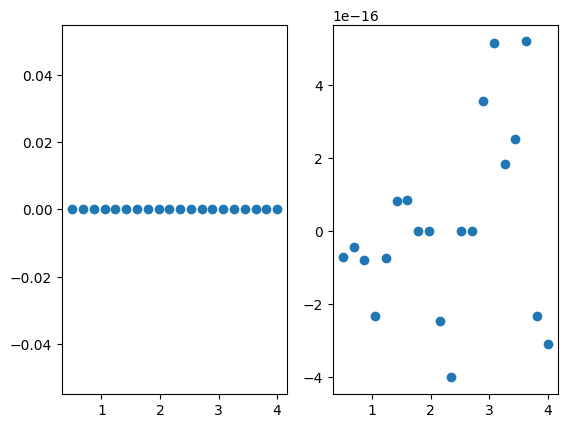

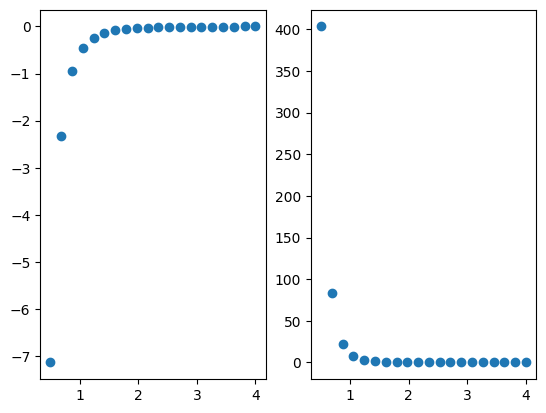

In [8]:
from scipy.optimize import minimize
def ratio(x,rx):
    h = x[0]
    d = np.array([np.sin(x[1]),np.cos(x[1])])
    R = np.array([rx,h])
    return -np.abs(dip_derivative_full(R,0,0,d,100)/dip_dip(R,d))

rx = np.linspace(0.5,4,N)
opt_h = np.ones(N)
opt_d1 = np.ones(N)
opt_ratio = np.zeros(N)
V = np.zeros(N)
V2 = np.zeros(N)
V_der = np.zeros(N)
V_der2 = np.zeros(N)
for i in range(N):
    res = minimize(ratio,x0=[opt_h[i-1],opt_d1[i-1]],args=(rx[i],),bounds=((0.15,1),(0,np.pi)))
    opt_h[i] = 0.2
    opt_d1[i] = np.arcsin(np.sqrt(1/3))
    opt_ratio[i] = res.fun
    V_der[i] = dip_derivative_full(np.array([rx[i],opt_h[i]]),0,0,np.array([np.sin(opt_d1[i]),np.cos(opt_d1[i])]),100)
    V[i] = dip_dip(np.array([rx[i],opt_h[i]]),np.array([np.sin(opt_d1[i]),np.cos(opt_d1[i])]))
    V2[i] = dip_dip(np.array([rx[i]*4/3,0]),np.array([np.sin(opt_d1[i]),np.cos(opt_d1[i])]))
    V_der2[i] = dip_derivative_full(np.array([rx[i]*4/3,0]),0,0,np.array([np.sin(opt_d1[i]),np.cos(opt_d1[i])]),100)


fig, ax = plt.subplots(1,2)
# ax[0].scatter(rx,opt_h)
# ax[0].scatter(rx,opt_d1)
ax[0].scatter(rx,V2/V)
ax[1].scatter(rx,V_der2/V_der)
fig2, ax2 = plt.subplots(1,2)
ax2[0].scatter(rx,V)
ax2[1].scatter(rx,V_der)
plt.show()





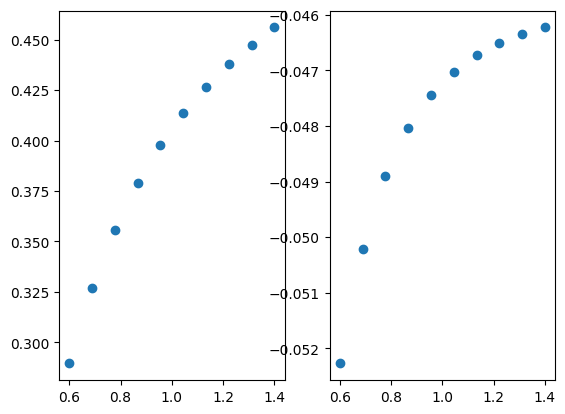

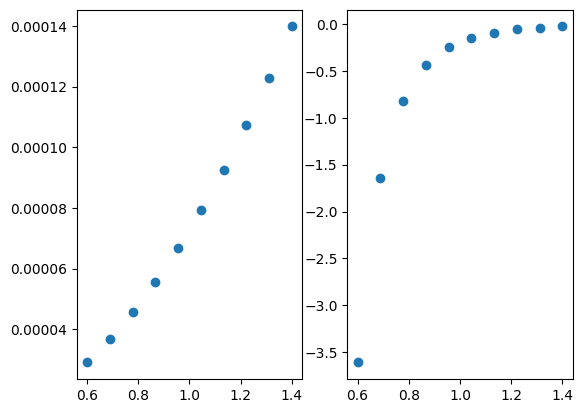

In [9]:
from scipy.optimize import root_scalar, minimize_scalar
def null(dx,R,sign):
    a = R[0]
    h = R[1]
    return 3*(a**2*dx**2+h**2*(1-dx**2)+sign*2*a*h*dx*np.sqrt(1-dx**2))-(a**2+h**2)
h = 0.35
N = 10
def ratio(h,rx):
    r = root_scalar(null,args=(np.array([rx,h]),1),bracket=(0,1))
    d = np.array([r.root,np.sqrt(1-r.root**2)])
    return np.abs(dip_derivative_full(np.array([rx,h]),0,0,d,100)/dip_derivative_full(np.array([rx*2,0]),0,0,d,100))
x = np.linspace(0.6,1.4,N)
opt_h = np.ones(N)*0.2
opt_d1 = np.ones(N)
opt_ratio = np.zeros(N)
V = np.zeros(N)
V2 = np.zeros(N)
V_der = np.zeros(N)
V_der2 = np.zeros(N)
for i in range(N):
    # res = minimize_scalar(ratio,args=(x[i],),bounds=((0.2,0.35)))
    opt_h[i] = 0.2#res.x
    r = root_scalar(null,args=(np.array([x[i],opt_h[i]]),1),bracket=(0,1))
    # r2 = root_scalar(null,args=(np.array([x[i],h]),-1),bracket=(0,1))
    opt_d1[i] = r.root
    V[i] = dip_dip(np.array([4*3*x[i],0]),np.array([opt_d1[i],np.sqrt(1-opt_d1[i]**2)]))
   
    V_der[i] = dip_derivative_full(np.array([x[i],opt_h[i]]),0,0,np.array([opt_d1[i],np.sqrt(1-opt_d1[i]**2)]),100)
    V_der2[i] = dip_derivative_full(np.array([x[i]*2,0]),0,0,np.array([opt_d1[i],np.sqrt(1-opt_d1[i]**2)]),100)

fig, ax = plt.subplots(1,2)
# ax[0].scatter(x,opt_h)
ax[0].scatter(x,opt_d1)
# ax[0].scatter(x,opt_ratio)
ax[1].scatter(x,V_der2/V_der)
fig2, ax2 = plt.subplots(1,2)
ax2[0].scatter(x,V/V_der)
ax2[1].scatter(x,V_der2)
plt.show()



In [19]:
import scipy.constants as c

a0 = 4*np.pi*c.epsilon_0*c.hbar**2/(c.m_e*c.e**2)
d = 1009*c.e*a0
r0 = 10/10**6
V = d**2/(4*np.pi*c.epsilon_0*r0**3)
V/c.h

992637.6911509775

In [16]:
c.e*a0

8.4783536197945e-30

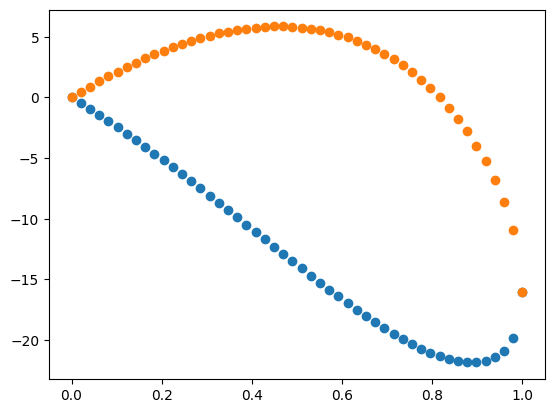

In [20]:
x = np.linspace(0,1)
y1 = -16*(x**2+np.sqrt(2*(1-x**2))*x)
y2 = -16*(x**2-np.sqrt(2*(1-x**2))*x)
fig, ax = plt.subplots(1,1)
ax.scatter(x,y1)
ax.scatter(x,y2)
plt.show()